# TP2 - Procesamiento global

## 0. Importacion de librerias

In [8]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# Configuracion general de graficos
plt.rcParams['figure.figsize'] = (8, 6)

## 1. Cargar imagenes

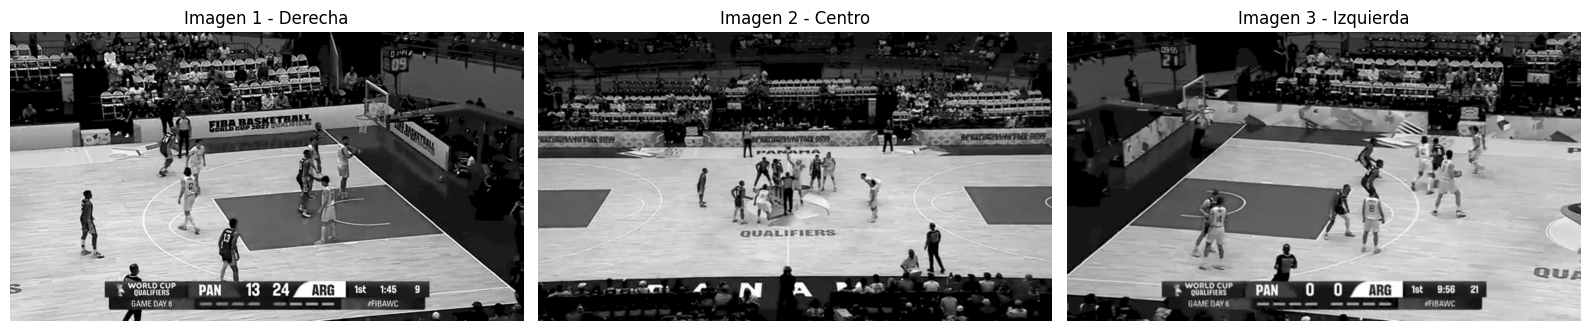

In [9]:
img1 = cv2.imread("img1.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("img-centro.png", cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread("img3.png", cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(img1, cmap="gray")
axes[0].set_title("Imagen 1 - Derecha")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray")
axes[1].set_title("Imagen 2 - Centro")
axes[1].axis("off")

axes[2].imshow(img3, cmap="gray")
axes[2].set_title("Imagen 3 - Izquierda")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 2. Metadatos

Datos a extraer:

- **Archivo**
- **Formato de archivo** (JPEG, PNG, BMP, etc.)
- **Tamaño en disco** (KB)
- **Modo de color** (RGB, escala de grises, RGBA, etc.)
- **Cantidad de canales**: 3 si es RGB
- **Profundidad de bits por canal**
- **Resolución espacial**: cantidad de píxeles en ancho x alto
- **Cantidad total de pixeles**: pixeles en ancho * pixeles en alto
- **Resolución radiométrica**: cantidad de niveles de intensidad posibles (2^bits)

In [10]:
def extraer_caracteristicas(path):
    im = Image.open(path)
    arr = np.array(im)

    ancho, alto = im.size
    total_pixeles = ancho * alto
    modo = im.mode

    # Bits por canal según el modo de PIL
    bits_por_canal_dict = {
        "1": 1, "L": 8, "P": 8, "RGB": 8, "RGBA": 8,
        "CMYK": 8, "I": 32, "F": 32
    }
    bits_por_canal = bits_por_canal_dict.get(modo, 8)
    n_canales = len(im.getbands())
    bits_por_pixel = bits_por_canal * n_canales

    # ¿Escala de grises?
    if modo == "L" or modo == "1":
        es_grises = True
    elif modo in ("RGB", "RGBA"):
        rgb = arr[..., :3]
        es_grises = bool(np.all(rgb[..., 0] == rgb[..., 1]) and np.all(rgb[..., 1] == rgb[..., 2]))
    else:
        es_grises = False

    # Niveles de gris/intensidad realmente utilizados
    if es_grises:
        canal_intensidad = arr if arr.ndim == 2 else arr[..., 0]
    else:
        canal_intensidad = np.array(im.convert("L"))
    niveles_usados = len(np.unique(canal_intensidad))

    dpi = im.info.get("dpi", "No especificado en los metadatos")
    tamano_disco_kb = os.path.getsize(path) / 1024

    caracteristicas = {
        "Archivo": os.path.basename(path),
        "Formato": im.format,
        "Tamaño en disco (KB)": round(tamano_disco_kb, 2),
        "Modo de color": modo,
        "Cantidad de canales": n_canales,
        "Profundidad de bits por canal": bits_por_canal,
        "Resolución espacial (ancho x alto)": f"{ancho} x {alto} px",
        "Total de píxeles": total_pixeles,
        "Resolución radiométrica (niveles posibles)": 2 ** bits_por_canal
    }
    return caracteristicas, arr


imgs = ["img1","img-centro","img3"]

for img_path in imgs:
    
  caracteristicas, arr_original = extraer_caracteristicas(f"{img_path}.png")

  print("=" * 60)
  print(f"CARACTERÍSTICAS DE LA IMAGEN - {img_path}")
  print("=" * 60)
  for clave, valor in caracteristicas.items():
      print(f"{clave:45s}: {valor}")
  print()


CARACTERÍSTICAS DE LA IMAGEN - img1
Archivo                                      : img1.png
Formato                                      : PNG
Tamaño en disco (KB)                         : 2469.88
Modo de color                                : RGBA
Cantidad de canales                          : 4
Profundidad de bits por canal                : 8
Resolución espacial (ancho x alto)           : 1920 x 1080 px
Total de píxeles                             : 2073600
Resolución radiométrica (niveles posibles)   : 256

CARACTERÍSTICAS DE LA IMAGEN - img-centro
Archivo                                      : img-centro.png
Formato                                      : PNG
Tamaño en disco (KB)                         : 2481.32
Modo de color                                : RGBA
Cantidad de canales                          : 4
Profundidad de bits por canal                : 8
Resolución espacial (ancho x alto)           : 1920 x 1080 px
Total de píxeles                             : 2073600
Resolu

## 3. Histograma y valores estadisticos asociados

### 3.1 Histograma

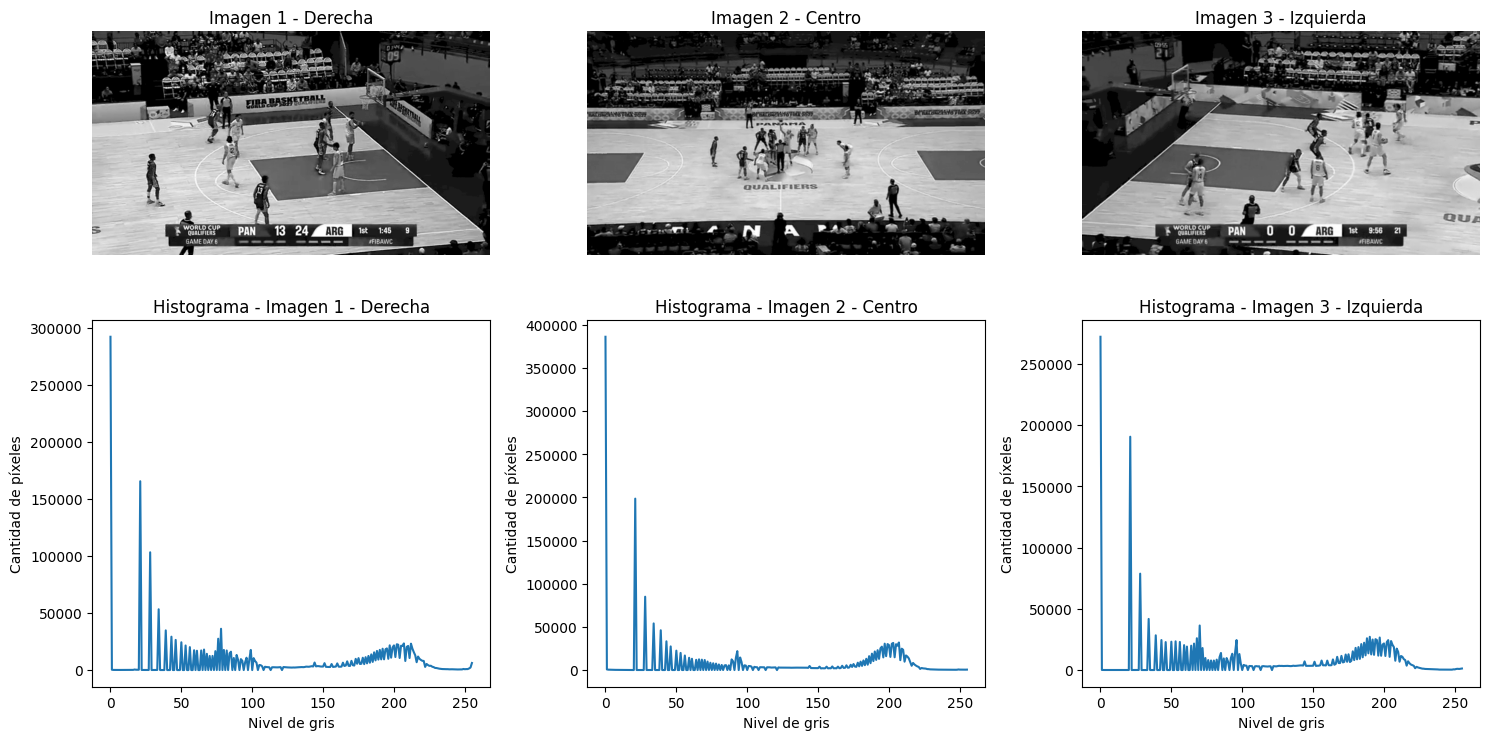

In [11]:
imagenes = [img1, img2, img3]
titulos = ["Imagen 1 - Derecha", "Imagen 2 - Centro", "Imagen 3 - Izquierda"]

fig, axes = plt.subplots(2, 3, figsize=(15,8))

# Fila 1: Imagenes
for i in range(3):
    axes[0, i].imshow(imagenes[i], cmap="gray")
    axes[0, i].set_title(titulos[i])
    axes[0, i].axis("off")

# Fila 2: Histogramas
for i in range(3):
    histograma = cv2.calcHist(
        [imagenes[i]],
        [0],
        None,
        [256],
        [0, 256]
    )

    axes[1, i].plot(histograma)
    axes[1, i].set_title("Histograma - " + titulos[i])
    axes[1, i].set_xlabel("Nivel de gris")
    axes[1, i].set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()


### 3.2 Valores estadisticos

In [12]:
for i in range(3):

    imagen = imagenes[i]

    media = np.mean(imagen)
    mediana = np.median(imagen)
    desvio = np.std(imagen)
    varianza = np.var(imagen)
    minimo = np.min(imagen)
    maximo = np.max(imagen)

    print("\n" + "=" * 50)
    print(titulos[i])
    print("=" * 50)

    print(f"Media:           {media:.2f}")
    print(f"Mediana:         {mediana:.2f}")
    print(f"Desvío estándar: {desvio:.2f}")
    print(f"Varianza:        {varianza:.2f}")
    print(f"Mínimo:          {minimo}")
    print(f"Máximo:          {maximo}")


Imagen 1 - Derecha
Media:           105.85
Mediana:         87.00
Desvío estándar: 80.25
Varianza:        6440.26
Mínimo:          0
Máximo:          255

Imagen 2 - Centro
Media:           101.84
Mediana:         89.00
Desvío estándar: 83.25
Varianza:        6929.90
Mínimo:          0
Máximo:          255

Imagen 3 - Izquierda
Media:           107.99
Mediana:         96.00
Desvío estándar: 78.01
Varianza:        6085.37
Mínimo:          0
Máximo:          255


## 4. Aplicaciones de tecnicas

### 4.1. Tecnica basada en procesamiento puntual

Realizadas en TP2-puntual

### 4.2. Tecnica de mejora de brillo y/o contraste

In [13]:
def expandir_contraste(imagen):
    """
    Expansión del histograma.
    Lleva el rango [IE_min, IE_max] al rango completo [0, 255].
    """
    pixels = np.array(imagen, dtype=np.float32)

    ie_min = pixels.min()
    ie_max = pixels.max()

    # Evitar división por cero si todos los píxeles tienen el mismo valor
    if ie_max == ie_min:
        return imagen

    salida = ((pixels - ie_min) / (ie_max - ie_min)) * 255

    return Image.fromarray(salida.astype(np.uint8))


def contraer_contraste(imagen, cmin=50, cmax=200):
    """
    Contracción del histograma.
    Lleva el rango [IE_min, IE_max] al rango [Cmin, Cmax].
    """
    pixels = np.array(imagen, dtype=np.float32)

    ie_min = pixels.min()
    ie_max = pixels.max()

    # Evitar división por cero
    if ie_max == ie_min:
        return imagen

    salida = (
        ((cmax - cmin) / (ie_max - ie_min))
        * (pixels - ie_min)
        + cmin
    )

    return Image.fromarray(salida.astype(np.uint8))

AttributeError: 'numpy.ndarray' object has no attribute 'getdata'

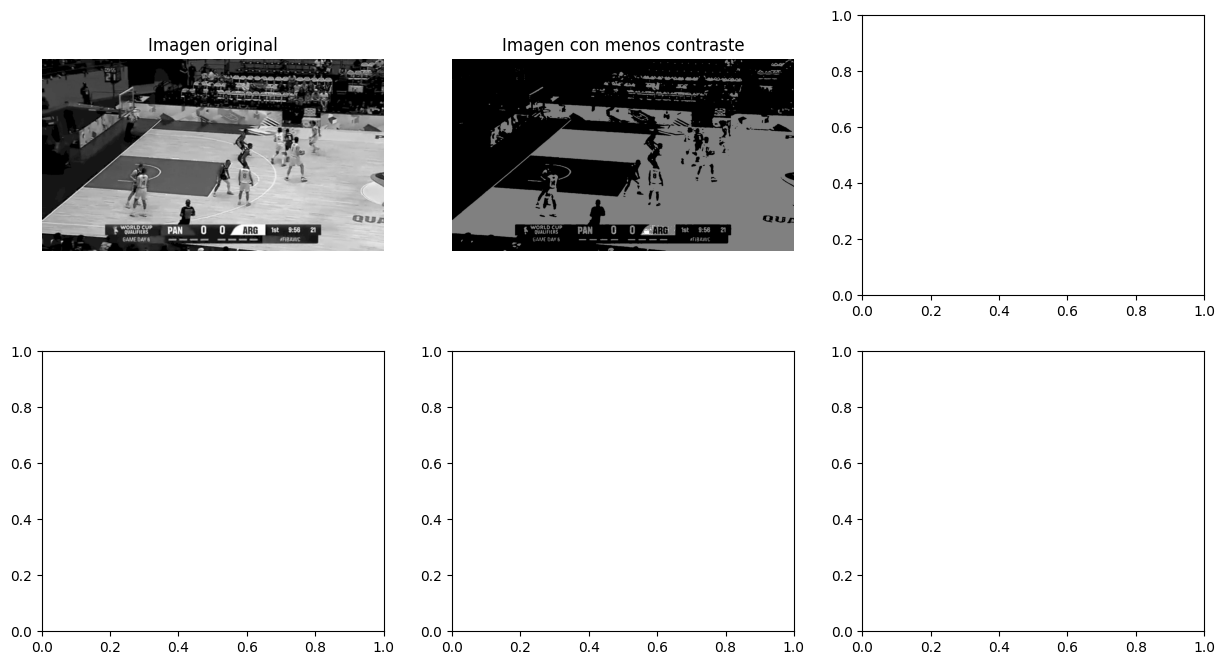

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# =========================
# Primera fila: imágenes
# =========================

imagenes = [
    imagen,
    contraer_contraste(imagen, 0, 2)
#    expandir_contraste(imagen)
]

titulos = [
    "Imagen original",
    "Imagen con menos contraste"
#    "Imagen con más contraste"
]

for i in range(2):
    axes[0, i].imshow(imagenes[i], cmap="gray")
    axes[0, i].set_title(titulos[i])
    axes[0, i].axis("off")


# =========================
# Segunda fila: histogramas
# =========================

for i in range(2):
    axes[1, i].hist(
        imagenes[i].getdata(),
        bins=256,
        range=(0, 256)
    )
    axes[1, i].set_xlabel("Nivel de gris")
    axes[1, i].set_ylabel("Cantidad de píxeles")
    axes[1, i].set_title(f"Histograma - {titulos[i]}")


plt.tight_layout()
plt.show()

### 4.3. Tecnica para identificar y tratar ruido

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

# Cargar imágenes en escala de grises
img1 = cv2.imread("img1.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("img2.png", cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread("img3.png", cv2.IMREAD_GRAYSCALE)

imagenes = [img1, img2, img3]
nombres = ["Imagen 1", "Imagen 2", "Imagen 3"]

# Verificar que se cargaron correctamente
for nombre, img in zip(nombres, imagenes):
    if img is None:
        print(f"Error al cargar {nombre}")
    else:
        print(f"{nombre}: {img.shape}")

Imagen 1: (1080, 1920)
Imagen 2: (1080, 1920)
Imagen 3: (1080, 1920)


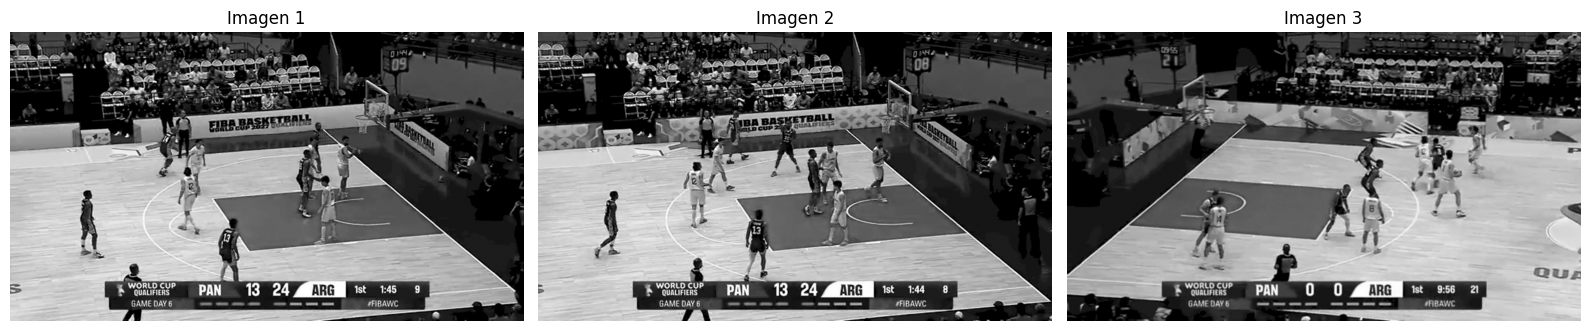

In [23]:
plt.figure(figsize=(16, 5))

for i, img in enumerate(imagenes):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(nombres[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
#Seleccionar una zona homogénea de cada imagen
rois = []

for i, img in enumerate(imagenes):

    # Seleccionar zona manualmente
    roi = cv2.selectROI(
        f"Seleccionar zona homogenea - {nombres[i]}",
        img,
        showCrosshair=True,
        fromCenter=False
    )

    rois.append(roi)

cv2.destroyAllWindows()

print("Regiones seleccionadas:")
for nombre, roi in zip(nombres, rois):
    print(nombre, roi)

Regiones seleccionadas:
Imagen 1 (835, 379, 137, 164)
Imagen 2 (372, 447, 146, 183)
Imagen 3 (777, 432, 80, 141)


In [25]:
#Medir el posible ruido antes del filtrado
estadisticas_antes = []

for nombre, img, roi in zip(nombres, imagenes, rois):

    x, y, w, h = roi

    # Extraer la zona seleccionada
    zona = img[y:y+h, x:x+w]

    # Estadísticas
    media = np.mean(zona)
    varianza = np.var(zona)
    desvio = np.std(zona)

    estadisticas_antes.append({
        "media": media,
        "varianza": varianza,
        "desvio": desvio
    })

    print(nombre)
    print(f"Media: {media:.2f}")
    print(f"Varianza: {varianza:.2f}")
    print(f"Desvío estándar: {desvio:.2f}")
    print("-----------------------------")

Imagen 1
Media: 141.01
Varianza: 4403.79
Desvío estándar: 66.36
-----------------------------
Imagen 2
Media: 199.83
Varianza: 239.38
Desvío estándar: 15.47
-----------------------------
Imagen 3
Media: 183.64
Varianza: 101.47
Desvío estándar: 10.07
-----------------------------


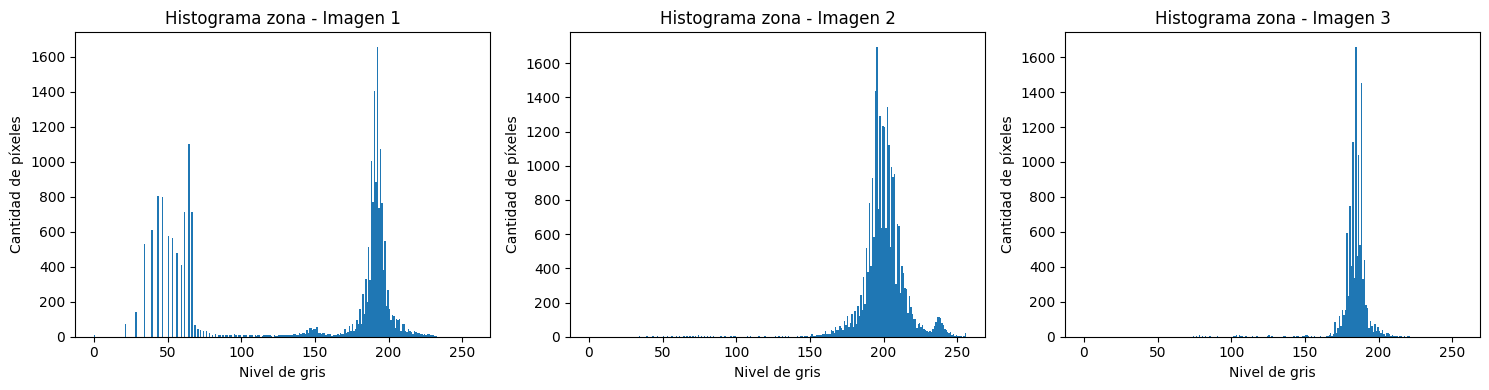

In [26]:
#histograma de las zonas analizadas
plt.figure(figsize=(15, 4))

for i, (img, roi) in enumerate(zip(imagenes, rois)):

    x, y, w, h = roi
    zona = img[y:y+h, x:x+w]

    plt.subplot(1, 3, i + 1)

    plt.hist(
        zona.ravel(),
        bins=256,
        range=(0, 256)
    )

    plt.title(f"Histograma zona - {nombres[i]}")
    plt.xlabel("Nivel de gris")
    plt.ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

### Filtro Gaussiano 3×3

In [39]:
imagenes_filtradas = []

for img in imagenes:

    # Filtro Gaussiano con máscara 3x3
    filtrada = cv2.GaussianBlur(
        img,
        (3, 3),
        0
    )

    imagenes_filtradas.append(filtrada)

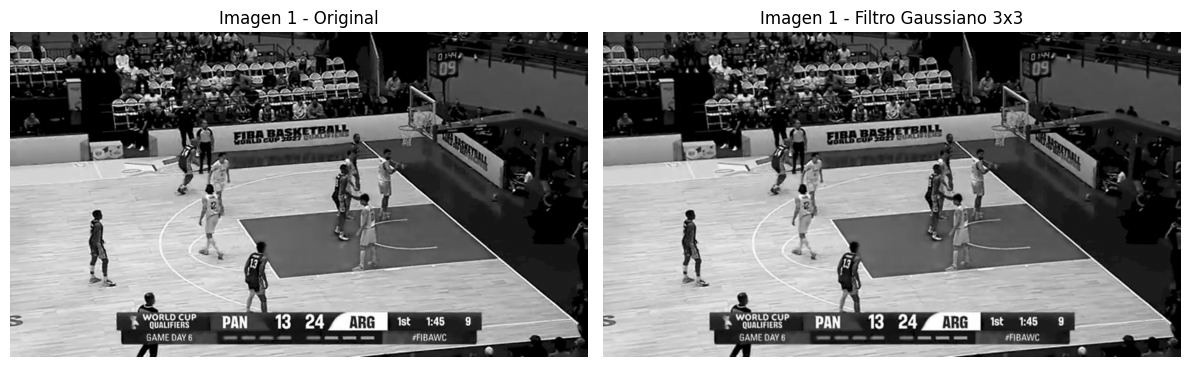

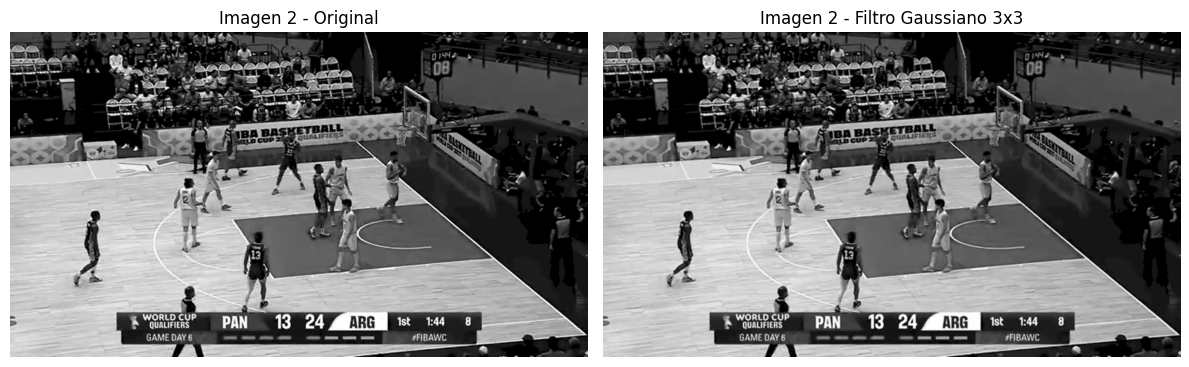

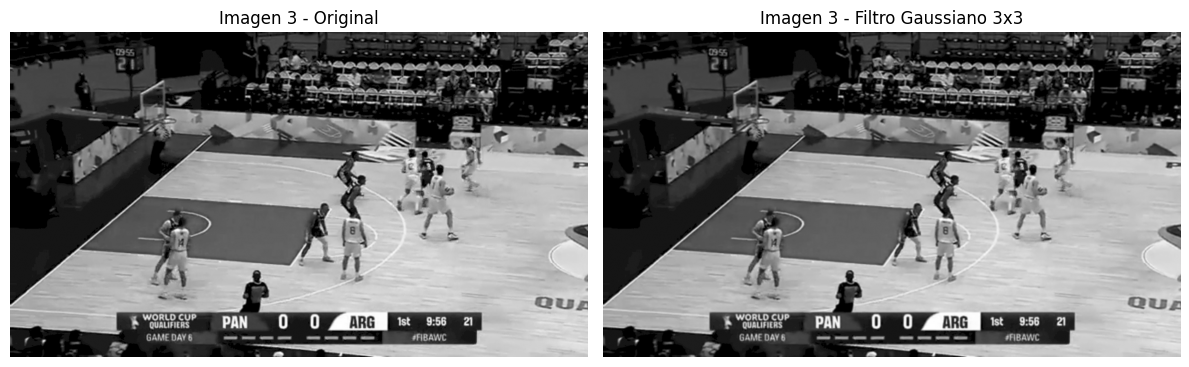

In [40]:
#Comparar original y filtrada
for i in range(3):

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(imagenes[i], cmap="gray")
    plt.title(f"{nombres[i]} - Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(imagenes_filtradas[i], cmap="gray")
    plt.title(f"{nombres[i]} - Filtro Gaussiano 3x3")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [41]:
#Medimos nuevamente la misma zona
estadisticas_despues = []

for nombre, img, roi in zip(
    nombres,
    imagenes_filtradas,
    rois
):

    x, y, w, h = roi

    zona = img[y:y+h, x:x+w]

    media = np.mean(zona)
    varianza = np.var(zona)
    desvio = np.std(zona)

    estadisticas_despues.append({
        "media": media,
        "varianza": varianza,
        "desvio": desvio
    })

    print(nombre)
    print(f"Media después: {media:.2f}")
    print(f"Varianza después: {varianza:.2f}")
    print(f"Desvío después: {desvio:.2f}")
    print("-----------------------------")

Imagen 1
Media después: 141.05
Varianza después: 4362.86
Desvío después: 66.05
-----------------------------
Imagen 2
Media después: 199.87
Varianza después: 218.75
Desvío después: 14.79
-----------------------------
Imagen 3
Media después: 183.63
Varianza después: 96.43
Desvío después: 9.82
-----------------------------


In [42]:
#Comparación antes vs. después
for i in range(3):

    antes = estadisticas_antes[i]
    despues = estadisticas_despues[i]

    print(nombres[i])

    print(
        f"Desvío estándar: "
        f"{antes['desvio']:.2f} -> "
        f"{despues['desvio']:.2f}"
    )

    print(
        f"Varianza: "
        f"{antes['varianza']:.2f} -> "
        f"{despues['varianza']:.2f}"
    )

    reduccion = (
        (antes["desvio"] - despues["desvio"])
        / antes["desvio"]
    ) * 100

    print(
        f"Reducción del desvío: "
        f"{reduccion:.2f}%"
    )

    print("--------------------------------")

Imagen 1
Desvío estándar: 66.36 -> 66.05
Varianza: 4403.79 -> 4362.86
Reducción del desvío: 0.47%
--------------------------------
Imagen 2
Desvío estándar: 15.47 -> 14.79
Varianza: 239.38 -> 218.75
Reducción del desvío: 4.41%
--------------------------------
Imagen 3
Desvío estándar: 10.07 -> 9.82
Varianza: 101.47 -> 96.43
Reducción del desvío: 2.51%
--------------------------------


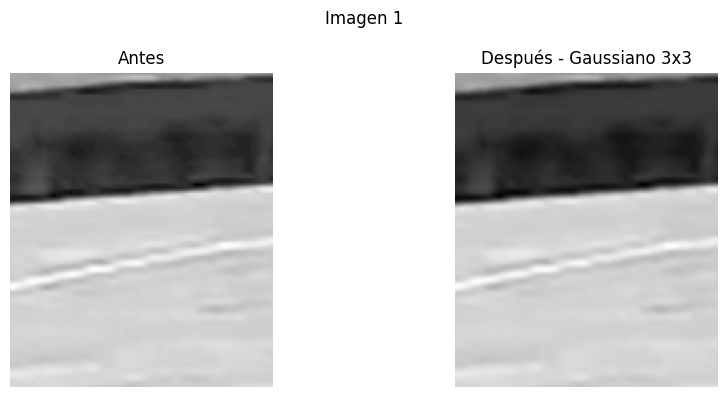

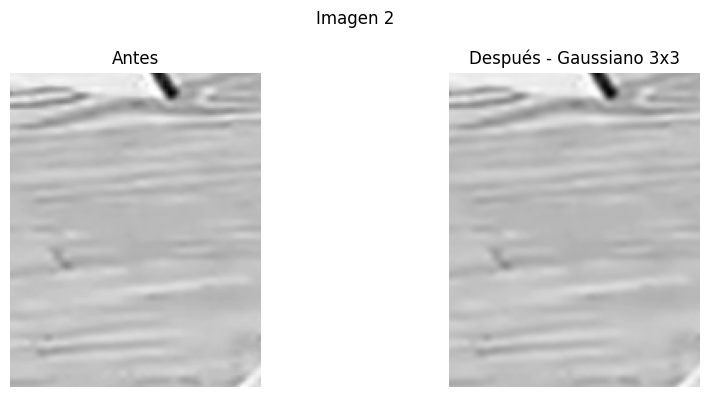

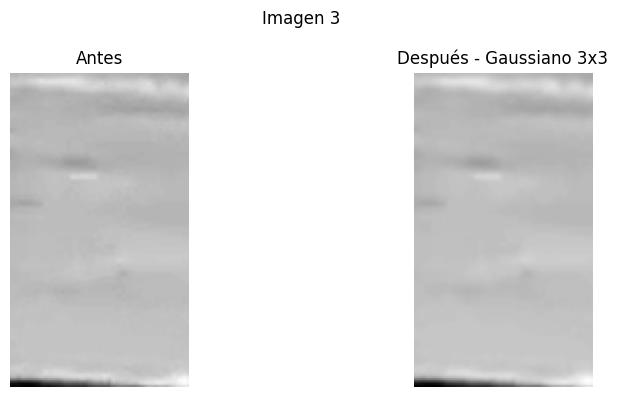

In [43]:
#Mostrar la zona antes y después
for i in range(3):

    x, y, w, h = rois[i]

    zona_original = imagenes[i][y:y+h, x:x+w]
    zona_filtrada = imagenes_filtradas[i][y:y+h, x:x+w]

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(zona_original, cmap="gray")
    plt.title("Antes")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(zona_filtrada, cmap="gray")
    plt.title("Después - Gaussiano 3x3")
    plt.axis("off")

    plt.suptitle(nombres[i])

    plt.tight_layout()
    plt.show()

### 4.4. Tecnica de detección de bordes

#### 4.3.1 Sobel

In [29]:
# Aplicar Sobel en X e Y
sobel_x1 = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
sobel_y1 = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)

sobel_x2 = cv2.Sobel(img2, cv2.CV_64F, 1, 0, ksize=3)
sobel_y2 = cv2.Sobel(img2, cv2.CV_64F, 0, 1, ksize=3)

sobel_x3 = cv2.Sobel(img3, cv2.CV_64F, 1, 0, ksize=3)
sobel_y3 = cv2.Sobel(img3, cv2.CV_64F, 0, 1, ksize=3)


# Calcular la magnitud del gradiente
sobel1 = cv2.magnitude(sobel_x1.astype(np.float32),
                       sobel_y1.astype(np.float32))

sobel2 = cv2.magnitude(sobel_x2.astype(np.float32),
                       sobel_y2.astype(np.float32))

sobel3 = cv2.magnitude(sobel_x3.astype(np.float32),
                       sobel_y3.astype(np.float32))


# Convertir a uint8 para visualizar
sobel1 = cv2.convertScaleAbs(sobel1)
sobel2 = cv2.convertScaleAbs(sobel2)
sobel3 = cv2.convertScaleAbs(sobel3)

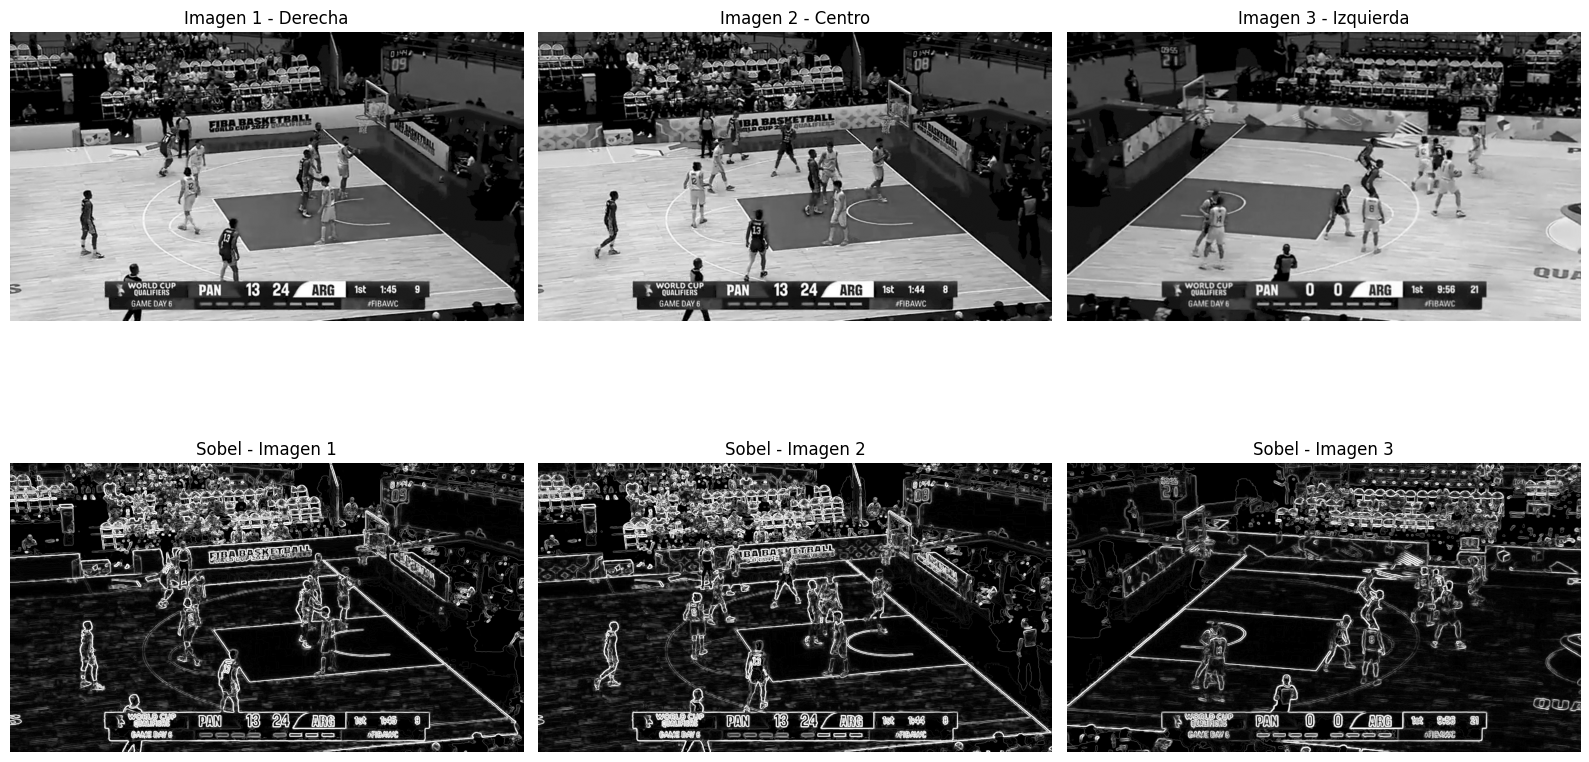

In [30]:
# Mostrar resultados
fig, axes = plt.subplots(2, 3, figsize=(16, 10))


# Imágenes originales
axes[0, 0].imshow(img1, cmap="gray")
axes[0, 0].set_title("Imagen 1 - Derecha")
axes[0, 0].axis("off")

axes[0, 1].imshow(img2, cmap="gray")
axes[0, 1].set_title("Imagen 2 - Centro")
axes[0, 1].axis("off")

axes[0, 2].imshow(img3, cmap="gray")
axes[0, 2].set_title("Imagen 3 - Izquierda")
axes[0, 2].axis("off")


# Resultados Sobel
axes[1, 0].imshow(sobel1, cmap="gray")
axes[1, 0].set_title("Sobel - Imagen 1")
axes[1, 0].axis("off")

axes[1, 1].imshow(sobel2, cmap="gray")
axes[1, 1].set_title("Sobel - Imagen 2")
axes[1, 1].axis("off")

axes[1, 2].imshow(sobel3, cmap="gray")
axes[1, 2].set_title("Sobel - Imagen 3")
axes[1, 2].axis("off")


plt.tight_layout()
plt.show()

#### 4.3.2 Laplaciano

In [31]:
laplaciano1 = cv2.Laplacian(img1, cv2.CV_64F)
laplaciano2 = cv2.Laplacian(img2, cv2.CV_64F)
laplaciano3 = cv2.Laplacian(img3, cv2.CV_64F)

# Convertir los resultados a uint8 para poder mostrarlos
laplaciano1 = cv2.convertScaleAbs(laplaciano1)
laplaciano2 = cv2.convertScaleAbs(laplaciano2)
laplaciano3 = cv2.convertScaleAbs(laplaciano3)

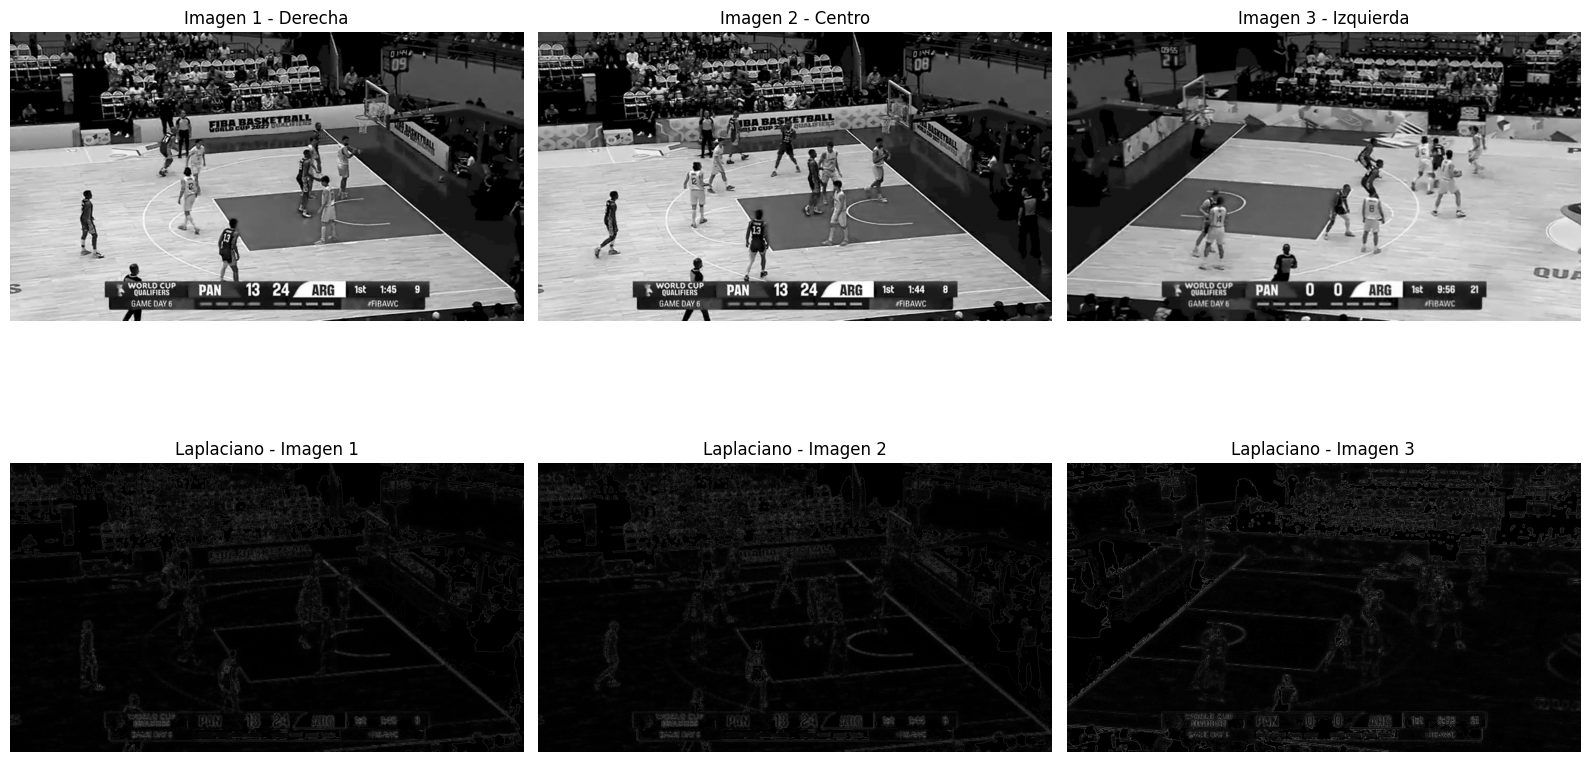

In [32]:
# Mostrar resultados
fig, axes = plt.subplots(2, 3, figsize=(16, 10))


# Imágenes originales
axes[0, 0].imshow(img1, cmap="gray")
axes[0, 0].set_title("Imagen 1 - Derecha")
axes[0, 0].axis("off")

axes[0, 1].imshow(img2, cmap="gray")
axes[0, 1].set_title("Imagen 2 - Centro")
axes[0, 1].axis("off")

axes[0, 2].imshow(img3, cmap="gray")
axes[0, 2].set_title("Imagen 3 - Izquierda")
axes[0, 2].axis("off")


# Resultados Laplaciano
axes[1, 0].imshow(laplaciano1, cmap="gray")
axes[1, 0].set_title("Laplaciano - Imagen 1")
axes[1, 0].axis("off")

axes[1, 1].imshow(laplaciano2, cmap="gray")
axes[1, 1].set_title("Laplaciano - Imagen 2")
axes[1, 1].axis("off")

axes[1, 2].imshow(laplaciano3, cmap="gray")
axes[1, 2].set_title("Laplaciano - Imagen 3")
axes[1, 2].axis("off")


plt.tight_layout()
plt.show()

#### 4.3.3 Laplaciano del Gaussiano (LOG)

In [33]:
# Aplicar desenfoque Gaussiano
gauss1 = cv2.GaussianBlur(img1, (5, 5), 0)
gauss2 = cv2.GaussianBlur(img2, (5, 5), 0)
gauss3 = cv2.GaussianBlur(img3, (5, 5), 0)


# Aplicar Laplaciano sobre las imágenes suavizadas
log1 = cv2.Laplacian(gauss1, cv2.CV_64F)
log2 = cv2.Laplacian(gauss2, cv2.CV_64F)
log3 = cv2.Laplacian(gauss3, cv2.CV_64F)


# Convertir los resultados a uint8
log1 = cv2.convertScaleAbs(log1)
log2 = cv2.convertScaleAbs(log2)
log3 = cv2.convertScaleAbs(log3)

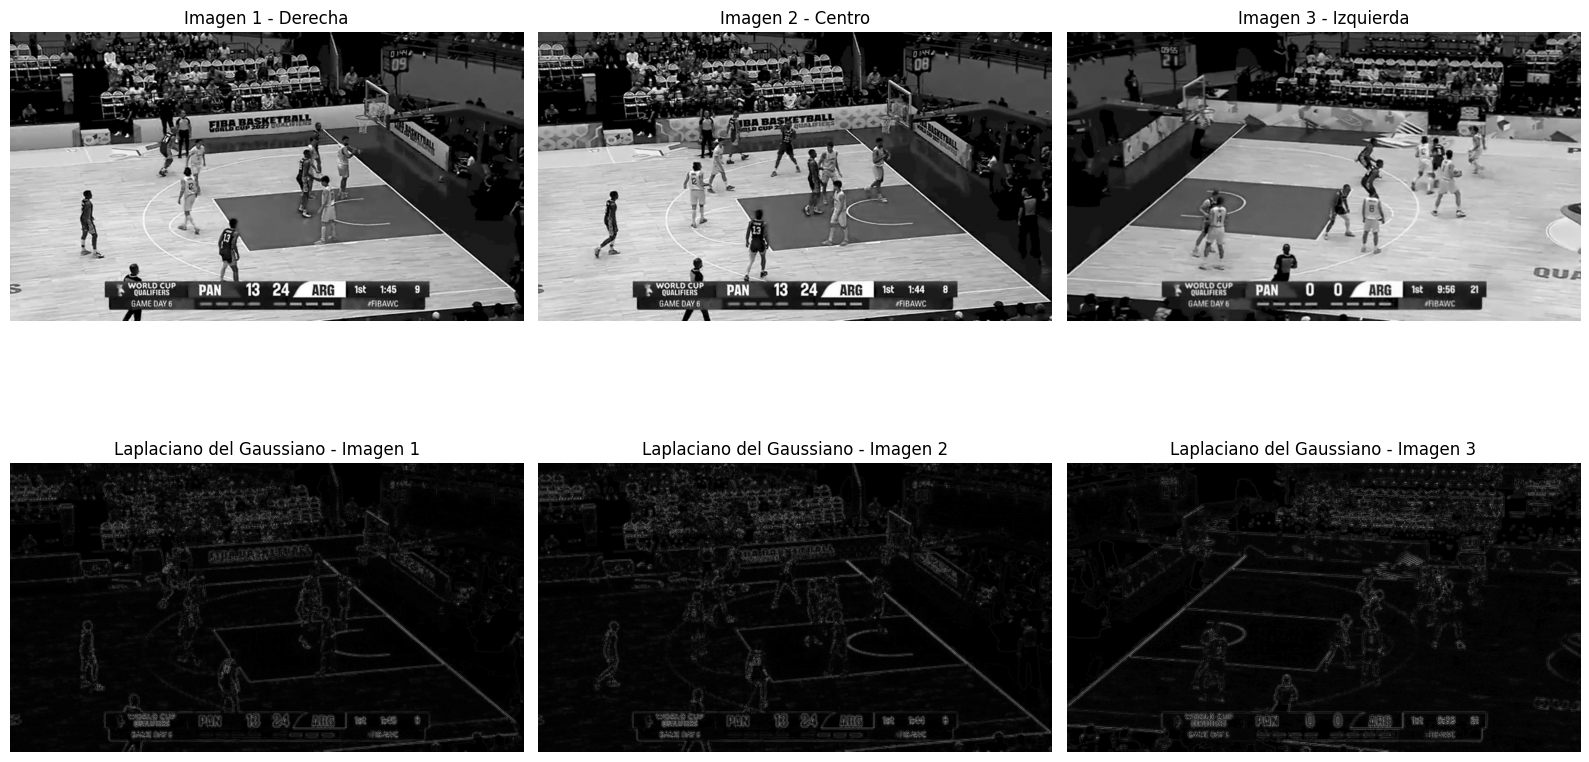

In [34]:
# Mostrar resultados
fig, axes = plt.subplots(2, 3, figsize=(16, 10))


# Imágenes originales
axes[0, 0].imshow(img1, cmap="gray")
axes[0, 0].set_title("Imagen 1 - Derecha")
axes[0, 0].axis("off")

axes[0, 1].imshow(img2, cmap="gray")
axes[0, 1].set_title("Imagen 2 - Centro")
axes[0, 1].axis("off")

axes[0, 2].imshow(img3, cmap="gray")
axes[0, 2].set_title("Imagen 3 - Izquierda")
axes[0, 2].axis("off")


# Resultados LoG
axes[1, 0].imshow(log1, cmap="gray")
axes[1, 0].set_title("Laplaciano del Gaussiano - Imagen 1")
axes[1, 0].axis("off")

axes[1, 1].imshow(log2, cmap="gray")
axes[1, 1].set_title("Laplaciano del Gaussiano - Imagen 2")
axes[1, 1].axis("off")

axes[1, 2].imshow(log3, cmap="gray")
axes[1, 2].set_title("Laplaciano del Gaussiano - Imagen 3")
axes[1, 2].axis("off")


plt.tight_layout()
plt.show()

#### 4.3.4. Canny

In [35]:
UMBRAL_INFERIOR = 100
UMBRAL_SUPERIOR = 200

In [36]:
canny1 = cv2.Canny(img1, UMBRAL_INFERIOR, UMBRAL_SUPERIOR)
canny2 = cv2.Canny(img2, UMBRAL_INFERIOR, UMBRAL_SUPERIOR)
canny3 = cv2.Canny(img3, UMBRAL_INFERIOR, UMBRAL_SUPERIOR)

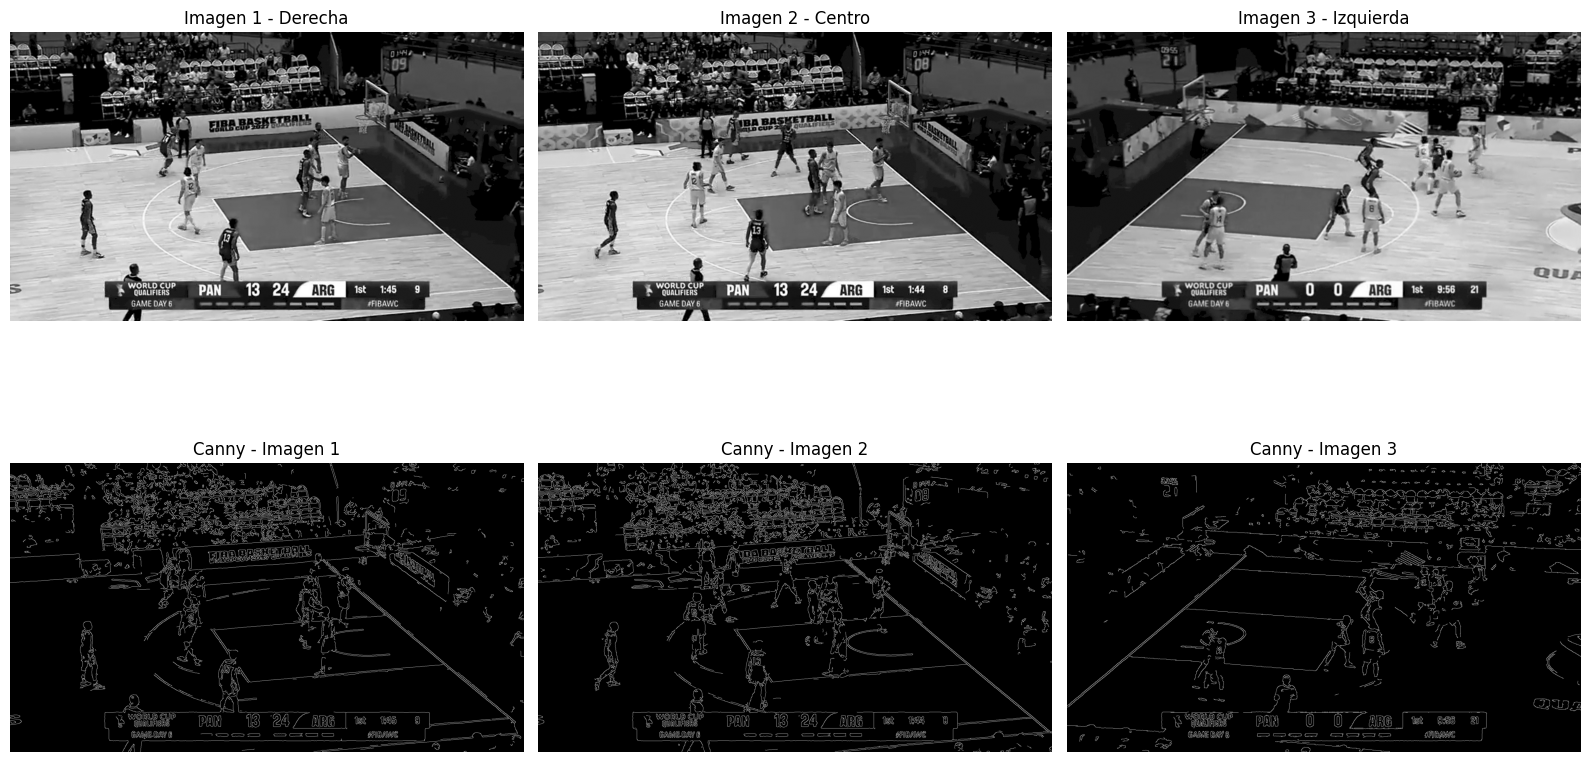

In [37]:
# Mostrar resultados
fig, axes = plt.subplots(2, 3, figsize=(16, 10))


# Imágenes originales
axes[0, 0].imshow(img1, cmap="gray")
axes[0, 0].set_title("Imagen 1 - Derecha")
axes[0, 0].axis("off")

axes[0, 1].imshow(img2, cmap="gray")
axes[0, 1].set_title("Imagen 2 - Centro")
axes[0, 1].axis("off")

axes[0, 2].imshow(img3, cmap="gray")
axes[0, 2].set_title("Imagen 3 - Izquierda")
axes[0, 2].axis("off")


# Resultados Canny
axes[1, 0].imshow(canny1, cmap="gray")
axes[1, 0].set_title("Canny - Imagen 1")
axes[1, 0].axis("off")

axes[1, 1].imshow(canny2, cmap="gray")
axes[1, 1].set_title("Canny - Imagen 2")
axes[1, 1].axis("off")

axes[1, 2].imshow(canny3, cmap="gray")
axes[1, 2].set_title("Canny - Imagen 3")
axes[1, 2].axis("off")


plt.tight_layout()
plt.show()

#### 4.3.5  Todos

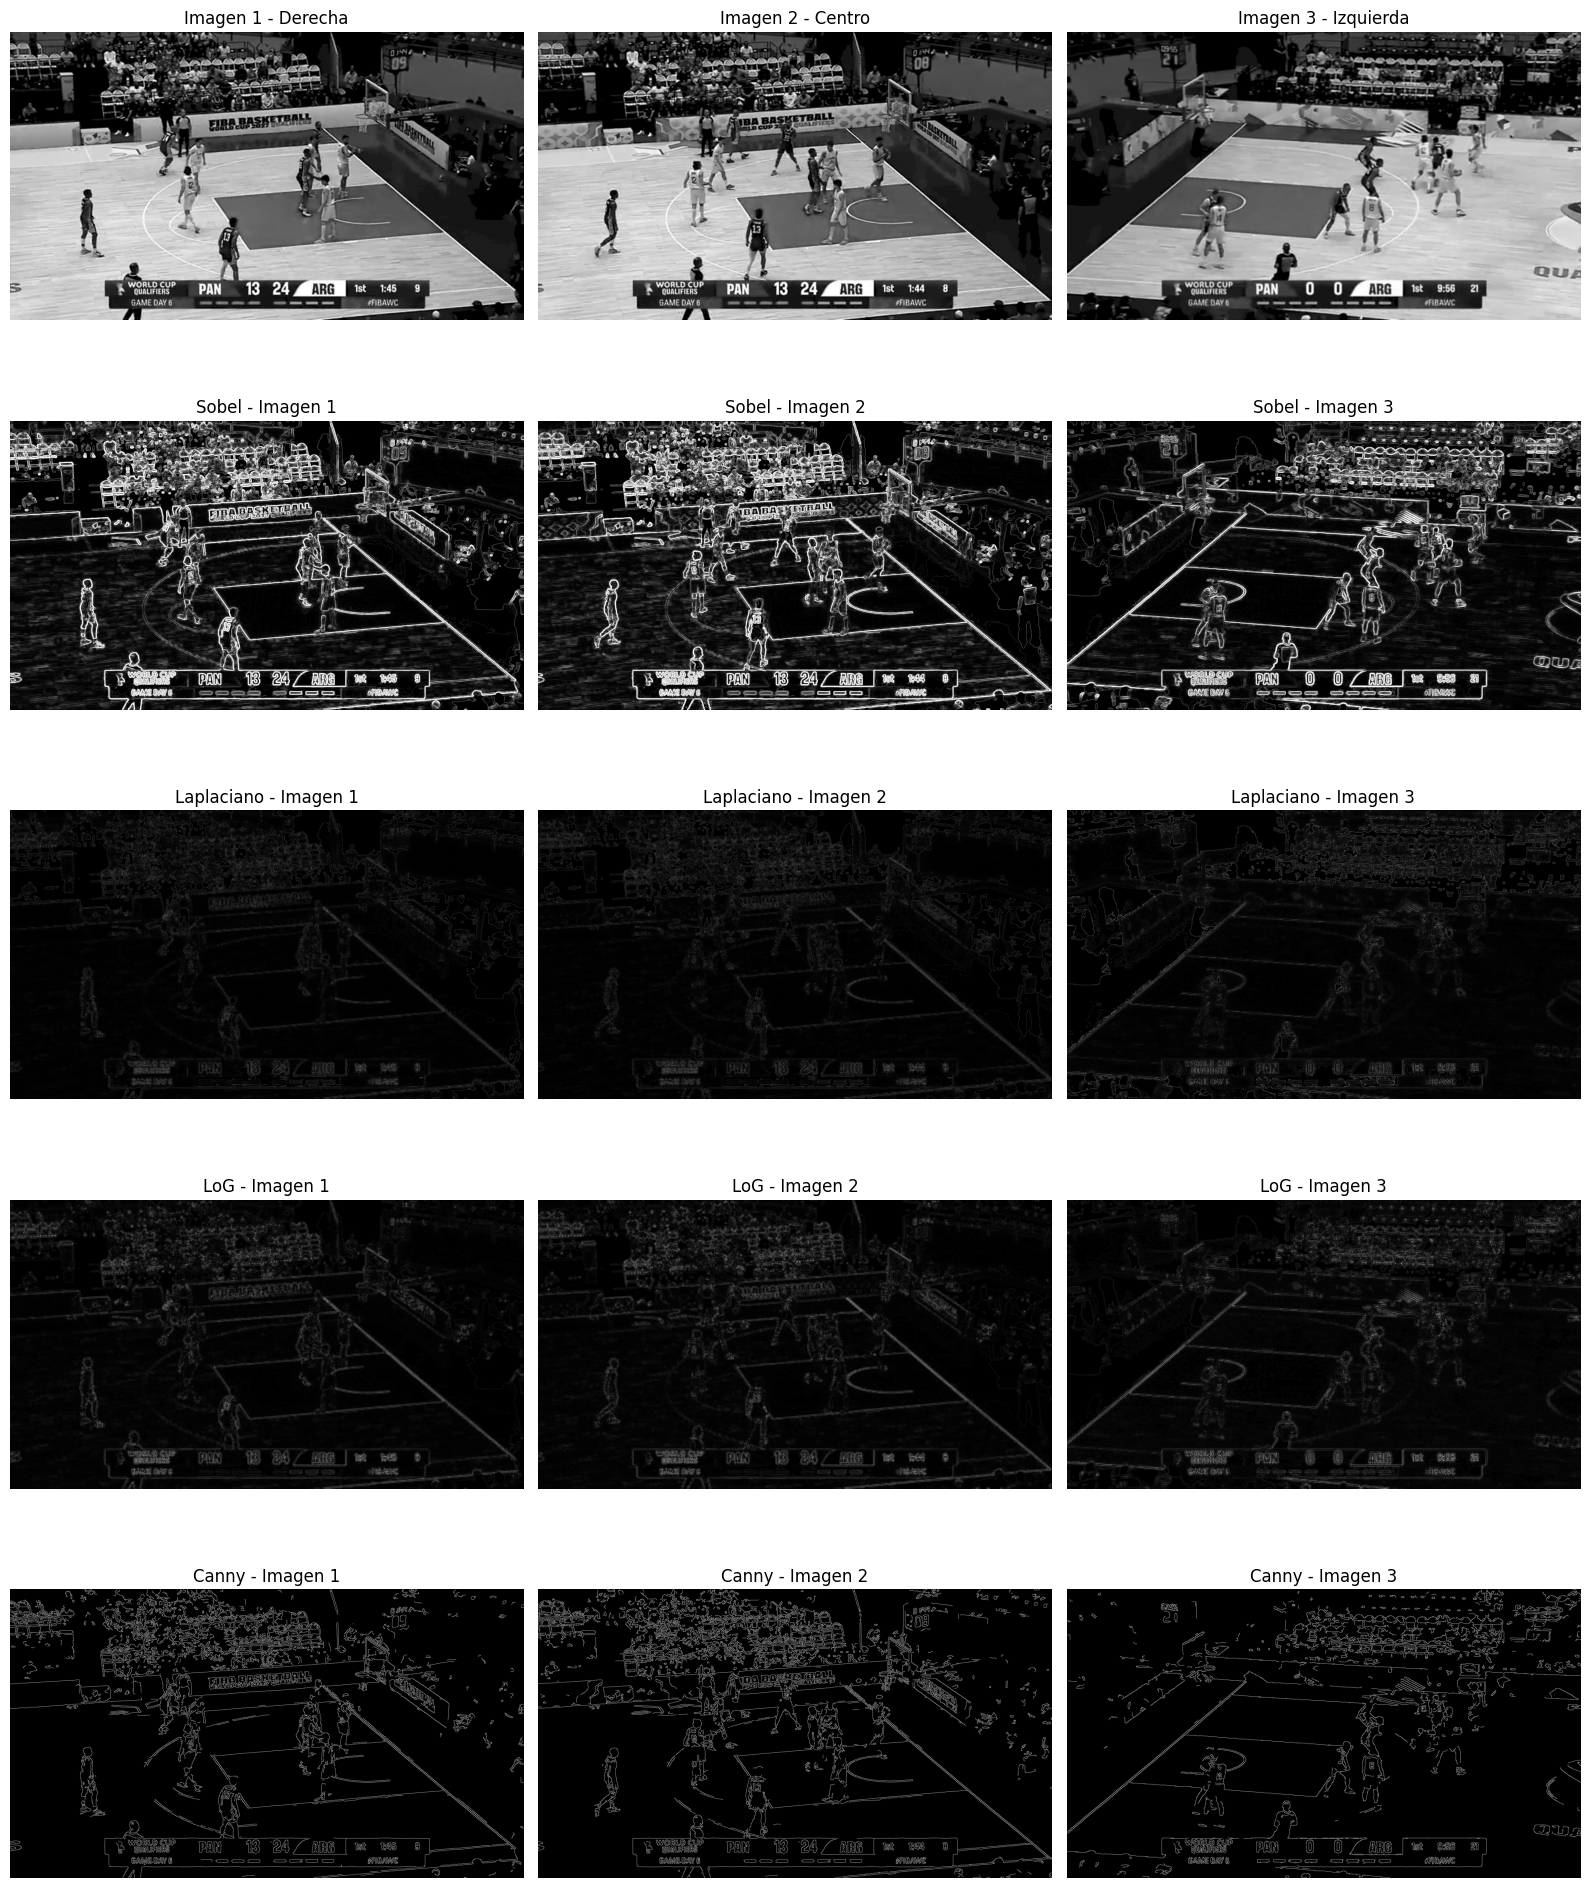

In [38]:
# Mostrar resultados
fig, axes = plt.subplots(5, 3, figsize=(16, 20))


# =========================
# Imagen original
# =========================

axes[0, 0].imshow(img1, cmap="gray")
axes[0, 0].set_title("Imagen 1 - Derecha")
axes[0, 0].axis("off")

axes[0, 1].imshow(img2, cmap="gray")
axes[0, 1].set_title("Imagen 2 - Centro")
axes[0, 1].axis("off")

axes[0, 2].imshow(img3, cmap="gray")
axes[0, 2].set_title("Imagen 3 - Izquierda")
axes[0, 2].axis("off")

# =========================
# Sobel
# =========================

axes[1, 0].imshow(sobel1, cmap="gray")
axes[1, 0].set_title("Sobel - Imagen 1")
axes[1, 0].axis("off")

axes[1, 1].imshow(sobel2, cmap="gray")
axes[1, 1].set_title("Sobel - Imagen 2")
axes[1, 1].axis("off")

axes[1, 2].imshow(sobel3, cmap="gray")
axes[1, 2].set_title("Sobel - Imagen 3")
axes[1, 2].axis("off")

# =========================
# Laplaciano
# =========================

axes[2, 0].imshow(laplaciano1, cmap="gray")
axes[2, 0].set_title("Laplaciano - Imagen 1")
axes[2, 0].axis("off")

axes[2, 1].imshow(laplaciano2, cmap="gray")
axes[2, 1].set_title("Laplaciano - Imagen 2")
axes[2, 1].axis("off")

axes[2, 2].imshow(laplaciano3, cmap="gray")
axes[2, 2].set_title("Laplaciano - Imagen 3")
axes[2, 2].axis("off")

# =========================
# Laplaciano del Gaussiano
# =========================

axes[3, 0].imshow(log1, cmap="gray")
axes[3, 0].set_title("LoG - Imagen 1")
axes[3, 0].axis("off")

axes[3, 1].imshow(log2, cmap="gray")
axes[3, 1].set_title("LoG - Imagen 2")
axes[3, 1].axis("off")

axes[3, 2].imshow(log3, cmap="gray")
axes[3, 2].set_title("LoG - Imagen 3")
axes[3, 2].axis("off")


# =========================
# Canny
# =========================

axes[4, 0].imshow(canny1, cmap="gray")
axes[4, 0].set_title("Canny - Imagen 1")
axes[4, 0].axis("off")

axes[4, 1].imshow(canny2, cmap="gray")
axes[4, 1].set_title("Canny - Imagen 2")
axes[4, 1].axis("off")

axes[4, 2].imshow(canny3, cmap="gray")
axes[4, 2].set_title("Canny - Imagen 3")
axes[4, 2].axis("off")

plt.tight_layout()
plt.show()

#4.4 RUIDO